In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load the datasets

events = pd.read_csv("events.csv")
users = pd.read_csv("users.csv")
subscriptions = pd.read_csv("subscriptions.csv")

In [8]:
print(events.shape)
print(users.shape)
print(subscriptions.shape)

(49978, 4)
(15000, 5)
(270, 5)


In [10]:
events.head()

,event_id,user_id,event_name,event_time
0,1,1,visit,2024-02-18 00:00:00
1,2,1,visit,2024-02-23 00:00:00
2,3,1,visit,2024-02-18 00:00:00
3,4,2,visit,2023-05-23 00:00:00
4,5,2,visit,2023-05-23 00:00:00


In [17]:
events["event_name"].unique()

array(['visit', 'signup', 'trial_start', 'subscription', 'cancel'],
      dtype=object)

# Product Funnel Conversion

In [16]:
# Check funnel counts in python

funnel_counts = {
    "Visit" : events[events["event_name"] == "visit"]["user_id"].nunique(),
    "Signup" : events[events["event_name"] == "signup"]["user_id"].nunique(),
    "Trial": events[events["event_name"] == "trial_start"]["user_id"].nunique(),
    "Paid" : events[events["event_name"] == "subscription"]["user_id"].nunique(),
}
funnel_counts

{'Visit': 15000, 'Signup': 3263, 'Trial': 1339, 'Paid': 270}

In [23]:
# Convert to DataFrame
funnel_df = pd.DataFrame(
                            list(funnel_counts.items()),
                            columns=["Stage","Users"]
)

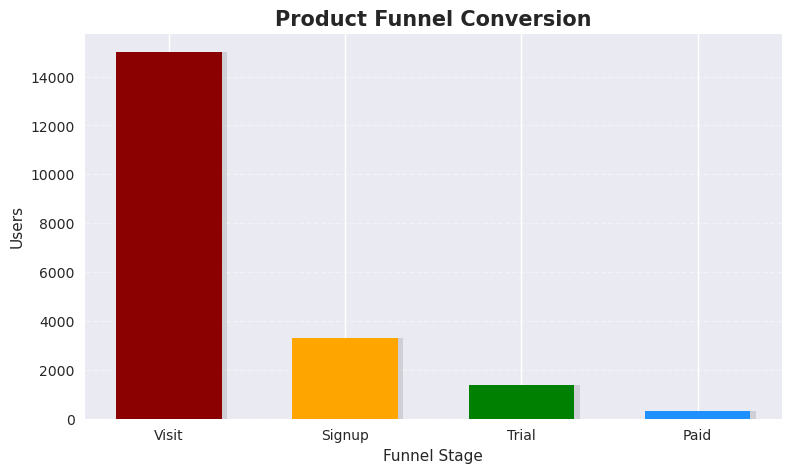

In [133]:
import matplotlib.pyplot as plt
import numpy as np

stages = ['Visit', 'Signup', 'Trial', 'Paid']
values = [15000, 3300, 1400, 300]   # replace with your funnel_counts values

colors = ['#8B0000', '#FFA500', '#008000', '#1E90FF']

plt.style.use('seaborn-v0_8')

fig, ax = plt.subplots(figsize=(9,5))

# create shadow bars
shadow = ax.bar(stages, values,
                color='gray',
                alpha=0.25,
                width=0.6)

for bar in shadow:
    bar.set_x(bar.get_x()+0.03)

# actual bars
bars = ax.bar(stages, values,
              color=colors,
              width=0.6,
              linewidth=1.2)

ax.set_title("Product Funnel Conversion", fontsize=15, weight='bold')
ax.set_xlabel("Funnel Stage")
ax.set_ylabel("Users")

ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

# Monthly Funnel Trend

In [41]:
events["event_time"] = pd.to_datetime(events["event_time"])  # convert the string to datetime object

events["month"] = events["event_time"].dt.to_period("M")  # extracts year + month 

monthly_funnel = events.pivot_table(
                                        index = "month",
                                        columns = "event_name",
                                        values = "user_id",
                                        aggfunc = pd.Series.nunique
)

monthly_funnel = monthly_funnel.fillna(0)

monthly_funnel.head()

event_name,cancel,signup,subscription,trial_start,visit
month,,,,,
2022-12,0.0,0.0,0.0,0.0,205.0
2023-01,0.0,186.0,20.0,85.0,939.0
2023-02,4.0,171.0,11.0,60.0,882.0
2023-03,2.0,195.0,7.0,80.0,981.0
2023-04,6.0,199.0,14.0,75.0,959.0


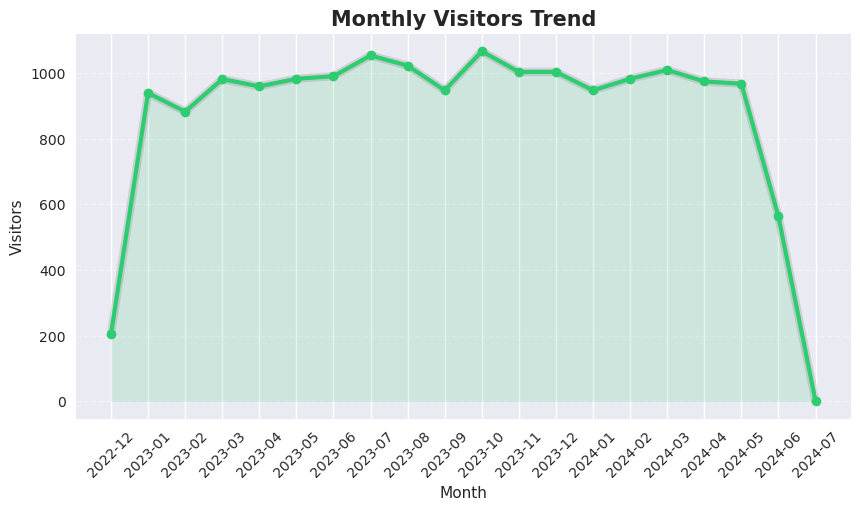

In [134]:
import matplotlib.pyplot as plt
import numpy as np

months = monthly_funnel.index.astype(str)
visitors = monthly_funnel["visit"]

plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(10,5))

# shadow line
ax.plot(months, visitors,
        linewidth=6,
        color="gray",
        alpha=0.25)

# main line
ax.plot(months, visitors,
        color="#2ecc71",
        linewidth=3,
        marker="o",
        markersize=7)

# gradient-like fill
ax.fill_between(months, visitors,
                color="#2ecc71",
                alpha=0.15)

ax.set_title("Monthly Visitors Trend", fontsize=15, weight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Visitors")

ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.xticks(rotation=45)

plt.show()

The monthly visitors trend remained relatively stable between 900 and 1050 users per month,
indicating consistent user acquisition. There were no major spikes or drops, suggesting 
marketing performance remained steady over the observed period.

# Monthly Signup Conversion Rate

In [47]:
monthly_funnel["signup_rate"] = (
                                    monthly_funnel["signup"] / monthly_funnel["visit"]
) * 100

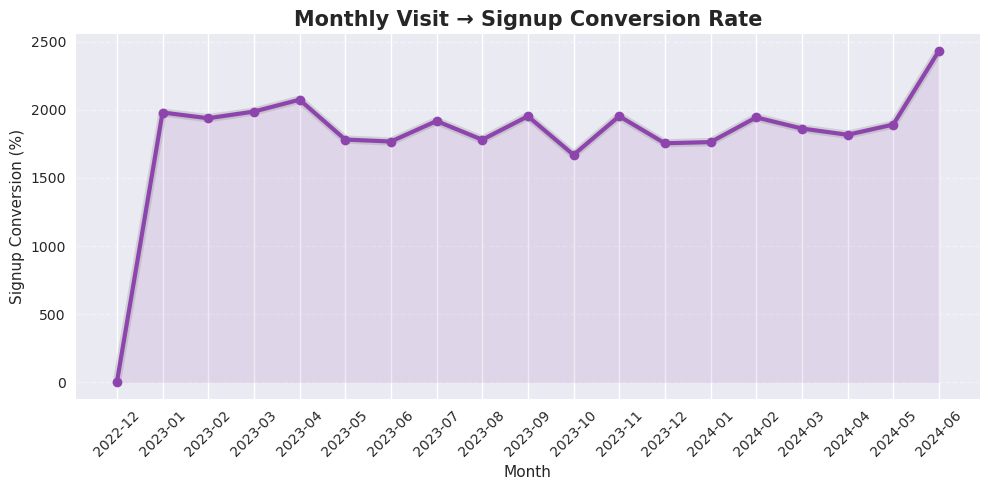

In [129]:
import matplotlib.pyplot as plt

months = monthly_funnel.index.astype(str)
conversion = monthly_funnel["signup_rate"] * 100

plt.figure(figsize=(10,5))

# shadow line
plt.plot(months, conversion,
         linewidth=6,
         color="gray",
         alpha=0.25)

# main line
plt.plot(months, conversion,
         color="#8e44ad",
         linewidth=3,
         marker="o",
         markersize=7)

# soft area fill
plt.fill_between(months, conversion,
                 color="#8e44ad",
                 alpha=0.12)


plt.title("Monthly Visit → Signup Conversion Rate",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Month")
plt.ylabel("Signup Conversion (%)")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

The visit-to-signup conversion rate remained relatively stable between 17% and 21% over the observed period, suggesting consistent landing page and onboarding performance. There were no major spikes or drops indicating product changes or marketing experiments during this time.

# Customer Retention

In [62]:
retention_data = {
                    "Active" : subscriptions["cancel_date"].isna().sum(),
                    "Churned" : subscriptions["cancel_date"].notna().sum()
}

retention_df = pd.DataFrame(
                                list(retention_data.items()),
                                columns = ["Status", "Users"]
)
retention_df

,Status,Users
0,Active,164
1,Churned,106


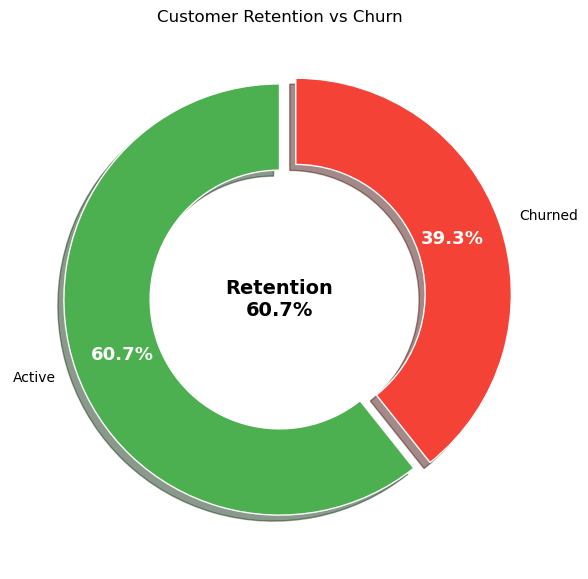

In [82]:
import matplotlib.pyplot as plt

labels = ['Active', 'Churned']
sizes = [60.7, 39.3]
colors = ['#4CAF50', '#F44336']

explode = (0, 0.08)  # highlight churn

fig, ax = plt.subplots(figsize=(7,7))

wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.77,
    startangle=90,
    explode=explode,
    shadow=True,
    wedgeprops={'width':0.4, 'edgecolor':'white'}
)

# Style percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(13)
    autotext.set_weight('bold')
    
ax.text(0,0,"Retention\n60.7%", ha='center', va='center', fontsize=14, weight='bold')

plt.title("Customer Retention vs Churn")

plt.show()

# Cohort Retention

In [86]:
subscriptions["start_date"] = pd.to_datetime(subscriptions["start_date"])
subscriptions["cancel_date"] = pd.to_datetime(subscriptions["cancel_date"])

# cohort month
subscriptions["cohort_month"] = subscriptions["start_date"].dt.to_period("M")

In [87]:
subscriptions.head()

,subscription_id,user_id,plan_type,start_date,cancel_date,cohort_month
0,1,43,monthly,2023-07-15,NaT,2023-07
1,2,52,monthly,2024-03-03,2024-03-10,2024-03
2,3,59,annual,2023-08-15,NaT,2023-08
3,4,184,monthly,2024-04-06,2024-04-06,2024-04
4,5,300,monthly,2024-06-17,NaT,2024-06


In [98]:
# Create Subscription End Date
subscriptions["end_date"] = subscriptions["cancel_date"].fillna(pd.Timestamp.today())

# Calculate Subscription Duration
subscriptions["tenture_days"] = (
                                    subscriptions["end_date"] - subscriptions["start_date"]
                                ).dt.days

# Convert Tenure into Months
subscriptions["tenure_months"] = (subscriptions["tenture_days"]/30).astype(int)

In [97]:
subscriptions.head()

,subscription_id,user_id,plan_type,start_date,cancel_date,cohort_month,end_date,tenture_days,tenture_months,tenure_months
0,1,43,monthly,2023-07-15,NaT,2023-07,2026-03-14 12:53:13.456,973,32,32
1,2,52,monthly,2024-03-03,2024-03-10,2024-03,2024-03-10 00:00:00.000,7,0,0
2,3,59,annual,2023-08-15,NaT,2023-08,2026-03-14 12:53:13.456,942,31,31
3,4,184,monthly,2024-04-06,2024-04-06,2024-04,2024-04-06 00:00:00.000,0,0,0
4,5,300,monthly,2024-06-17,NaT,2024-06,2026-03-14 12:53:13.456,635,21,21


In [101]:
# Build Cohort Table
cohort_data = subscriptions.groupby(
                                        ["cohort_month","tenure_months"]
                                   )["user_id"].nunique().reset_index()

cohort_data.head()

,cohort_month,tenure_months,user_id
0,2023-01,0,1
1,2023-01,1,2
2,2023-01,37,2
3,2023-01,38,15
4,2023-02,0,3


In [103]:
# Pivot Table

cohort_table = cohort_data.pivot_table(
                                            index = "cohort_month",
                                            columns = "tenure_months",
                                            values = "user_id"
)

In [113]:
# Convert to Retention Percentage

cohort_sizes = cohort_table.iloc[:,0]
retention_table = cohort_table.divide(cohort_sizes,axis=0)
retention_table = retention_table.iloc[:, :12]

In [114]:
# Convert Cohort Table to Numeric Matrix

cohort_matrix = retention_table.values
cohort_labels = retention_table.index.astype(str)
month_labels = retention_table.columns

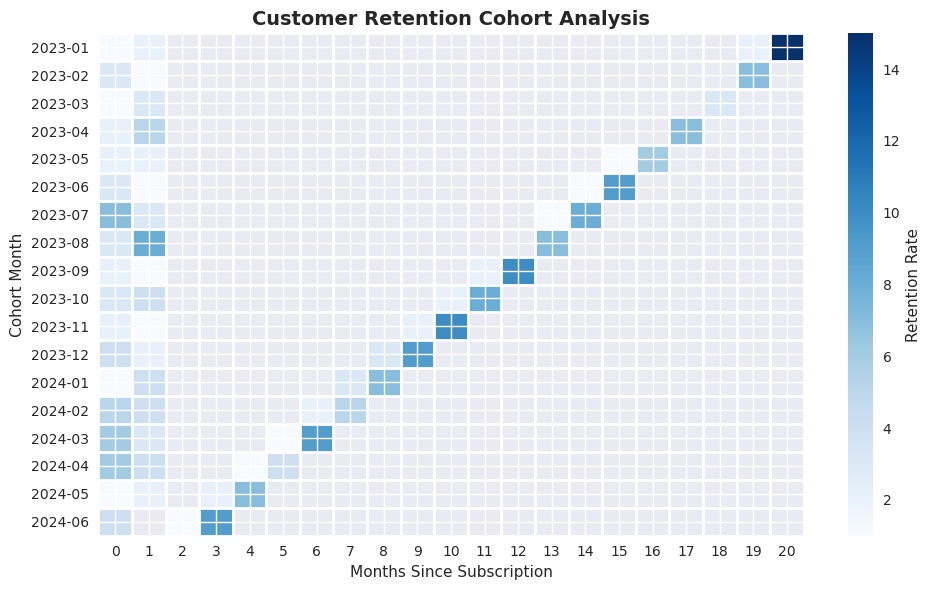

In [138]:
import matplotlib.pyplot as plt
import numpy as np

data = cohort_table.values

fig, ax = plt.subplots(figsize=(10,6))

heatmap = ax.imshow(data, cmap="Blues", aspect="auto")

# ---- FIX: use sequential months instead of cohort_table column names ----
num_months = len(cohort_table.columns)

ax.set_xticks(np.arange(num_months))
ax.set_xticklabels(range(num_months))   # 0,1,2,3... instead of 0,1,20,21...

ax.set_yticks(np.arange(len(cohort_table.index)))
ax.set_yticklabels(cohort_table.index)

# grid lines between cells
ax.set_xticks(np.arange(-.5, num_months, 1), minor=True)
ax.set_yticks(np.arange(-.5, len(cohort_table.index), 1), minor=True)

ax.grid(which="minor", color="white", linestyle='-', linewidth=2)
ax.tick_params(which="minor", bottom=False, left=False)

# colorbar
cbar = fig.colorbar(heatmap)
cbar.set_label("Retention Rate")

ax.set_title("Customer Retention Cohort Analysis",
             fontsize=14,
             fontweight="bold")

ax.set_xlabel("Months Since Subscription")
ax.set_ylabel("Cohort Month")

plt.tight_layout()
plt.show()